# Paired CVaR vs CDaR — Risk-Geometry Comparison

This notebook is the controlled comparison requested by the research design. It expects the matched YAML arms:

- `scripts/configs/bayessian_cvar_paired.yaml` → `results/bayessian_cvar_paired_walk_forward/`
- `scripts/configs/bayessian_cdar.yaml` → `results/bayessian_cdar_walk_forward/`

The scientific treatment is the optimizer risk geometry: terminal-loss CVaR versus path-drawdown CDaR. The notebook compares realized performance, drawdown/CDaR, pathwise return differences, forward-risk states, active holdings, L1 weight distance, turnover and paired/block-bootstrap uncertainty.

In [12]:
%matplotlib inline
import os,sys,subprocess,warnings,json
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if ROOT.name.lower() in {"notebook","notebooks"}: ROOT=ROOT.parent
RESULTS=ROOT/"results"; sys.path.insert(0,str(ROOT))
RF=0.02; SEED=42
CVAR_DIR=RESULTS/"bayessian_cvar_paired_walk_forward"
CDAR_DIR=RESULTS/"bayessian_cdar_walk_forward"
PAIR_DIR=RESULTS/"cvar_cdar_comparison"
print(CVAR_DIR); print(CDAR_DIR)


/Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cvar_paired_walk_forward
/Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_forward


## 0. Optionally run the matched pair and comparison script

In [ ]:
# RUN_MATCHED_PAIR=True # if we want to run matches
RUN_MATCHED_PAIR=False

if RUN_MATCHED_PAIR:
    env=os.environ.copy(); env["PYTHONPATH"]=str(ROOT)
    for cfg in ["bayessian_cvar_paired.yaml","bayessian_cdar.yaml"]:
        cmd=[sys.executable,"scripts/runs/run.py","-c",cfg]; print(" ".join(cmd))
        p=subprocess.run(cmd,cwd=str(ROOT),env=env)
        if p.returncode!=0: raise RuntimeError(f"failed {cfg}")
    cmd=[sys.executable,"scripts/runs/compare_cvar_cdar.py","--cvar-dir",str(CVAR_DIR),"--cdar-dir",str(CDAR_DIR),"--output-dir",str(PAIR_DIR)]
    p=subprocess.run(cmd,cwd=str(ROOT),env=env)
    if p.returncode!=0: raise RuntimeError("compare_cvar_cdar failed")
else:
    print("Analysis-only mode")


/usr/local/bin/python3 scripts/runs/run.py -c bayessian_cvar_paired.yaml


2026-09-28 01:32:08.069 | INFO     | __main__:main:754 - Successful file reading
2026-09-28 01:32:12.166 | INFO     | __main__:model_computation:326 - Run start: portfolio=filteredmodel=bayessian, optimizer=bayessian, execution=base_exec
Portfolio optimization with 0 month weight rebalancing 2019-01-02 00:00:00: : 0it [00:00, ?it/s]2026-09-28 01:32:12.443 | WARNING  | __main__:model_computation:496 - Nested engine fallback on 2019-01-02: "['BOND'] not in index"
Portfolio optimization with 1 month weight rebalancing 2019-02-01 00:00:00: : 1it [00:00,  2.85it/s]

self.is_all_methods=False, self.min_weight=0.0, self.max_weight=0.12
single_methods
[RC-LP] method_type='return_cvar_constraint' sum=1.0000 active=41
IN-SAMPLE execution grid: alpha=0.1, result=[ 8.93715625e+02 -1.06284375e-01  1.61364929e-04 -1.06284375e-01]. IN-SAMPLE alpha grid-search best
best_index=np.int64(0) np.sum(w_target)=np.float64(1.0) case[index%2]='max_alpha'
0.5 2019-02-01 00:00:00 1077.8508776725664 0.07785087767256646 0.0008068246445497629 0.07785087767256638
PROGRESS	2019-02-01	211	41	0.07785087767256638	1077.8508776725664


2026-09-28 01:32:12.759 | WARNING  | __main__:model_computation:496 - Nested engine fallback on 2019-02-01: "['BOND'] not in index"
Portfolio optimization with 2 month weight rebalancing 2019-03-01 00:00:00: : 2it [00:00,  3.08it/s]

self.is_all_methods=False, self.min_weight=0.0, self.max_weight=0.12
single_methods
[RC-LP] method_type='return_cvar_constraint' sum=1.0000 active=42
IN-SAMPLE execution grid: alpha=1.0, result=[1.10987760e+03 2.97134976e-02 9.22085308e-04 2.97134976e-02]. IN-SAMPLE alpha grid-search best
best_index=np.int64(0) np.sum(w_target)=np.float64(1.0) case[index%2]='max_alpha'
0.478755922504349 2019-03-01 00:00:00 1111.0506597847664 0.03080183242406339 0.0004414538022864747 0.030801832424063313
PROGRESS	2019-03-01	213	42	0.030801832424063313	1111.0506597847664


...

Portfolio optimization with 82 month weight rebalancing 2025-11-03 00:00:00: : 82it [1:39:06, 39.00s/it]2026-09-28 03:13:59.890 | WARNING  | __main__:model_computation:496 - Nested engine fallback on 2025-11-03: "['AVDV', 'AVUS', 'AVUV', 'BITB', 'BITO', 'BND', 'CGDV', 'CGGR', 'DVY', 'DYNF', 'EMB', 'ETHA', 'GBTC', 'IBB', 'IBIT', 'IEF', 'IEI', 'IJT', 'JAAA', 'JEPI', 'JEPQ', 'MBB', 'MCHI', 'MSTY', 'QQQM', 'SCZ', 'SGOV', 'SHY', 'SPYM', 'TBIL', 'TLT', 'VONE', 'VONG', 'VONV', 'VTWO', 'VXUS'] not in index"


self.is_all_methods=False, self.min_weight=0.0, self.max_weight=0.12
single_methods
IN-SAMPLE execution grid: alpha=1.0, result=[3.48007498e+03 1.30247968e-01 5.67589022e-04 1.30247968e-01]. IN-SAMPLE alpha grid-search best
best_index=np.int64(0) np.sum(w_target)=np.float64(1.0) case[index%2]='max_alpha'
0.5339875146427786 2025-12-01 00:00:00 2737.5156078872596 -0.11091816511413168 0.00030308545100389534 -0.11091816511413166
PROGRESS	2025-12-01	239	13	-0.11091816511413166	2737.5156078872596


Portfolio optimization with 82 month weight rebalancing 2025-11-03 00:00:00: : 83it [1:39:55, 72.23s/it]
2026-09-28 03:14:48.006 | INFO     | scripts.results.results:save_results:114 - preds_df info successfully saved to /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_forward/preds.csv
2026-09-28 03:14:48.015 | INFO     | scripts.results.results:save_results:119 - real_df info successfully saved to /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_forward/real.csv
2026-09-28 03:14:48.016 | INFO     | scripts.results.results:save_results:124 - model_df info successfully saved to /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_forward/model.csv
2026-09-28 03:14:48.016 | INFO     | scripts.results.results:save_results:129 - pnl_df info successfully saved to /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_f

Interactive Plotly report saved to /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/bayessian_cdar_walk_forward/interactive_report.html


2026-09-28 03:17:02.773 | INFO     | __main__:main:792 - SUCCESS


## 1. Load aligned monthly returns and common performance metrics

In [14]:
def load_pnl(folder):
    p=folder/"pnl.csv"
    if not p.exists(): raise FileNotFoundError(p)
    x=pd.read_csv(p); first=x.columns[0]; x[first]=pd.to_datetime(x[first]); x=x.rename(columns={first:"date"}).set_index("date").sort_index()
    for c in ["Balance","PnL","Cost","Returns","Alpha"]:
        if c in x: x[c]=pd.to_numeric(x[c],errors="coerce")
    return x

def dd(r):
    w=(1+r).cumprod(); return w/w.cummax()-1

def tailmean(x,a=.95):
    x=pd.Series(x).dropna().astype(float); q=x.quantile(a); return float(x[x>=q].mean()) if len(x) else np.nan

def metrics(p):
    r=p.Returns.dropna(); r=r.iloc[1:] if len(r) and abs(r.iloc[0])<1e-15 else r
    n=len(r); total=float((1+r).prod()-1); ann=(1+total)**(12/n)-1; vol=r.std()*np.sqrt(12)
    ex=r-RF/12; sh=ex.mean()/ex.std()*np.sqrt(12); d=dd(r); mdd=d.min(); q=r.quantile(.05); cv=r[r<=q].mean(); cd=tailmean((-d).clip(lower=0),.95)
    downside=np.sqrt(np.mean(np.minimum(r.to_numpy(),0)**2))*np.sqrt(12)
    return {"Months":n,"Cumulative %":100*total,"Annualized %":100*ann,"Volatility %":100*vol,"Sharpe":sh,
            "Sortino":(ann-RF)/downside if downside>0 else np.nan,"MaxDD %":100*mdd,"CVaR95 %":100*cv,"CDaR95 %":100*cd,
            "Mean cost":p.Cost.mean() if "Cost" in p else np.nan,"Mean alpha":p.Alpha.mean() if "Alpha" in p else np.nan}

cvar=load_pnl(CVAR_DIR); cdar=load_pnl(CDAR_DIR)
common=cvar.index.intersection(cdar.index)
cvar=cvar.loc[common]; cdar=cdar.loc[common]
print("Aligned rows:",len(common),common.min(),common.max())
display(pd.DataFrame({"CVaR":metrics(cvar),"CDaR":metrics(cdar)}).T.round(4))


Aligned rows: 84 2019-01-02 00:00:00 2025-12-01 00:00:00


,Months,Cumulative %,Annualized %,Volatility %,Sharpe,Sortino,MaxDD %,CVaR95 %,CDaR95 %,Mean cost,Mean alpha
CVaR,83.0,175.6258,15.7872,20.9324,0.7113,1.1535,-15.3407,-10.6919,14.2419,0.0003,0.5160
CDaR,83.0,173.7516,15.6731,19.2741,0.7505,1.2512,-14.1114,-9.5561,12.7685,0.0003,0.5153


## 2. Wealth, drawdown and rolling 12-month risk

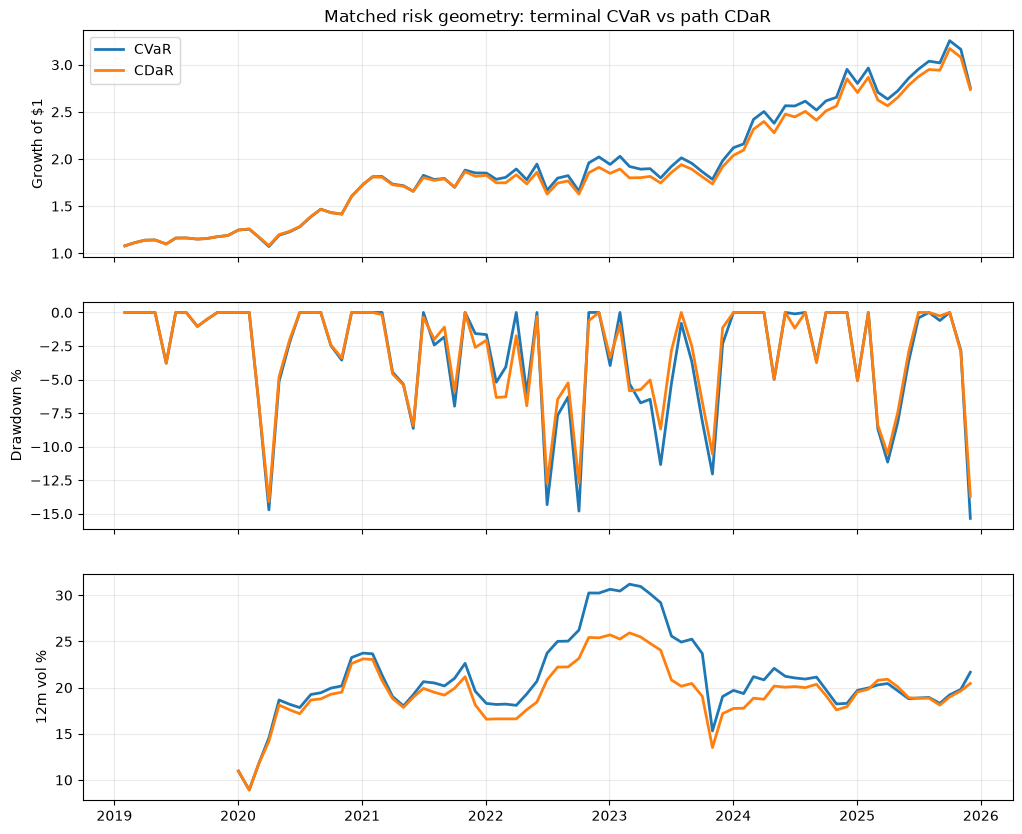

In [15]:
fig,axes=plt.subplots(3,1,figsize=(12,10),sharex=True)
for label,p in [("CVaR",cvar),("CDaR",cdar)]:
    r=p.Returns.dropna(); r=r.iloc[1:] if len(r) and abs(r.iloc[0])<1e-15 else r
    axes[0].plot(r.index,(1+r).cumprod(),label=label,lw=2)
    axes[1].plot(r.index,100*dd(r),label=label,lw=2)
    axes[2].plot(r.index,100*r.rolling(12).std()*np.sqrt(12),label=label,lw=2)
axes[0].set_ylabel("Growth of $1"); axes[1].set_ylabel("Drawdown %"); axes[2].set_ylabel("12m vol %")
axes[0].set_title("Matched risk geometry: terminal CVaR vs path CDaR"); axes[0].legend()
for a in axes: a.grid(alpha=.25)
plt.show()


## 3. Month-by-month treatment effect

count    83.000000
mean     -0.000353
std       0.008296
min      -0.042509
25%      -0.001681
50%       0.000000
75%       0.003266
max       0.018425
Name: CDaR_minus_CVaR, dtype: float64


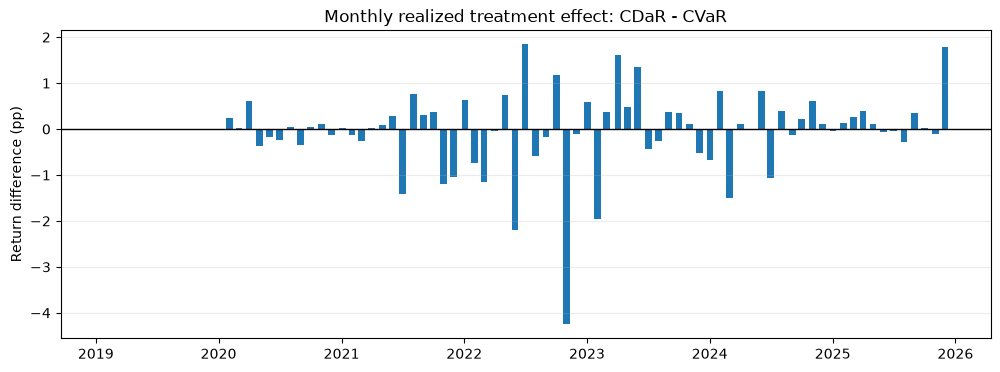

In [16]:
r=pd.concat([cvar.Returns.rename("CVaR"),cdar.Returns.rename("CDaR")],axis=1).dropna()
if len(r) and np.allclose(r.iloc[0],0): r=r.iloc[1:]
r["CDaR_minus_CVaR"]=r.CDaR-r.CVaR
print(r["CDaR_minus_CVaR"].describe())
fig,ax=plt.subplots(figsize=(12,4)); ax.bar(r.index,100*r.CDaR_minus_CVaR,width=20)
ax.axhline(0,color="black",lw=1); ax.set_ylabel("Return difference (pp)"); ax.set_title("Monthly realized treatment effect: CDaR - CVaR")
ax.grid(axis="y",alpha=.25); plt.show()


## 4. Paired moving-block bootstrap

The block bootstrap preserves local serial dependence better than i.i.d. resampling. It reports the distribution of **CDaR minus CVaR** in Sharpe and maximum drawdown depth.

In [17]:
def sharpe(x):
    x=np.asarray(x,float); ex=x-RF/12
    return ex.mean()/ex.std(ddof=1)*np.sqrt(12) if len(x)>1 and ex.std(ddof=1)>0 else np.nan

def mdd(x):
    x=pd.Series(np.asarray(x,float)); return float(dd(x).min())

def moving_block_indices(n,L,rng):
    k=int(np.ceil(n/L)); starts=rng.integers(0,max(1,n-L+1),size=k)
    idx=np.concatenate([np.arange(s,min(s+L,n)) for s in starts])
    if len(idx)<n:
        idx=np.resize(idx,n)
    return idx[:n]

B=5000; L=6; rng=np.random.default_rng(SEED)
a=r.CVaR.to_numpy(); b=r.CDaR.to_numpy(); ds=[]
for _ in range(B):
    ix=moving_block_indices(len(r),L,rng)
    ds.append((sharpe(b[ix])-sharpe(a[ix]), mdd(b[ix])-mdd(a[ix])))
boot=pd.DataFrame(ds,columns=["delta_sharpe","delta_maxdd"])
summary=pd.DataFrame({
    "estimate":[sharpe(b)-sharpe(a),mdd(b)-mdd(a)],
    "boot_mean":[boot.delta_sharpe.mean(),boot.delta_maxdd.mean()],
    "q025":[boot.delta_sharpe.quantile(.025),boot.delta_maxdd.quantile(.025)],
    "q975":[boot.delta_sharpe.quantile(.975),boot.delta_maxdd.quantile(.975)],
    "P(CDaR better)":[(boot.delta_sharpe>0).mean(),(boot.delta_maxdd>0).mean()],
},index=["Sharpe difference","MaxDD difference (higher=shallower)"])
display(summary)


,estimate,boot_mean,q025,q975,P(CDaR better)
Sharpe difference,0.039225,0.027742,-0.041571,0.094824,0.7938
MaxDD difference (higher=shallower),0.012293,0.016336,-0.007391,0.046088,0.9306


## 5. Compare internal risk states exported by both arms

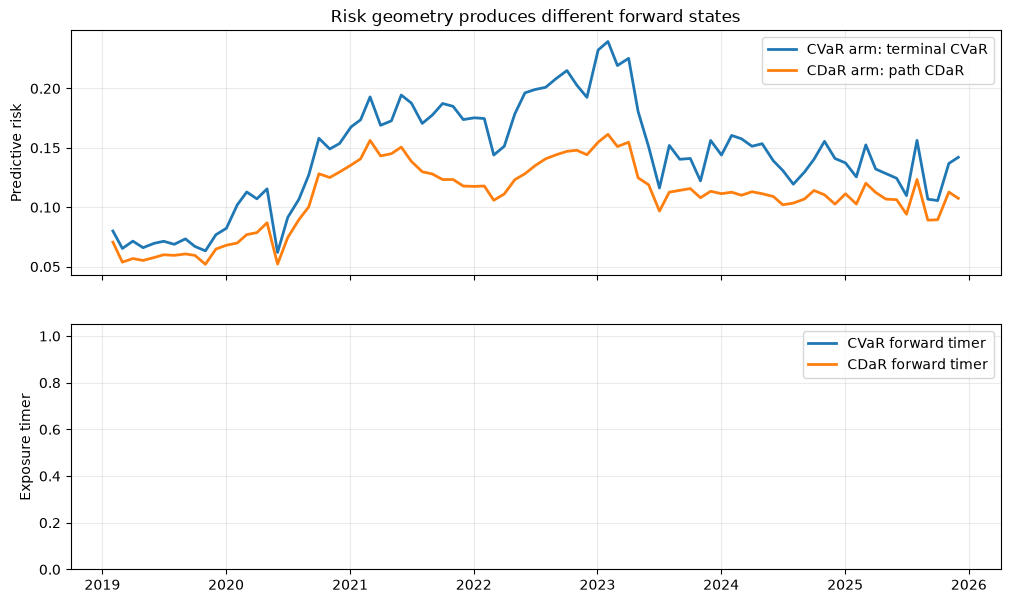

In [18]:
def fr(folder):
    p=folder/"forecast_risk.csv"
    if not p.exists(): return None
    x=pd.read_csv(p); x["date"]=pd.to_datetime(x["date"]); return x.set_index("date")
fc=fr(CVAR_DIR); fd=fr(CDAR_DIR)
if fc is None or fd is None:
    print("forecast_risk.csv missing in one arm")
else:
    ix=fc.index.intersection(fd.index); fc=fc.loc[ix]; fd=fd.loc[ix]
    cols=["cvar_model_centered","cdar_model_centered","forward_cvar_timer","forward_cdar_timer","forward_risk_timer","overlay_fraction"]
    for c in cols:
        if c in fc: fc[c]=pd.to_numeric(fc[c],errors="coerce")
        if c in fd: fd[c]=pd.to_numeric(fd[c],errors="coerce")
    fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
    if "cvar_model_centered" in fc: axes[0].plot(ix,fc.cvar_model_centered,label="CVaR arm: terminal CVaR",lw=2)
    if "cdar_model_centered" in fd: axes[0].plot(ix,fd.cdar_model_centered,label="CDaR arm: path CDaR",lw=2)
    if "forward_risk_timer" in fc: axes[1].plot(ix,fc.forward_risk_timer,label="CVaR forward timer",lw=2)
    if "forward_risk_timer" in fd: axes[1].plot(ix,fd.forward_risk_timer,label="CDaR forward timer",lw=2)
    axes[0].set_ylabel("Predictive risk"); axes[1].set_ylabel("Exposure timer"); axes[1].set_ylim(0,1.05)
    for a in axes: a.grid(alpha=.25); a.legend()
    axes[0].set_title("Risk geometry produces different forward states"); plt.show()


## 6. Weight distance, active-holding overlap and turnover

,count,mean,std,min,25%,50%,75%,max
l1_weight_distance,83.0,0.235006,0.194387,0.000000,0.049679,0.206786,0.392787,0.626086
jaccard,83.0,0.884644,0.088842,0.734694,0.813953,0.860465,1.000000,1.000000
cvar_active,83.0,83.722892,76.034221,34.000000,38.000000,41.000000,135.000000,218.000000
cdar_active,83.0,86.445783,74.468565,36.000000,41.000000,46.000000,136.000000,218.000000


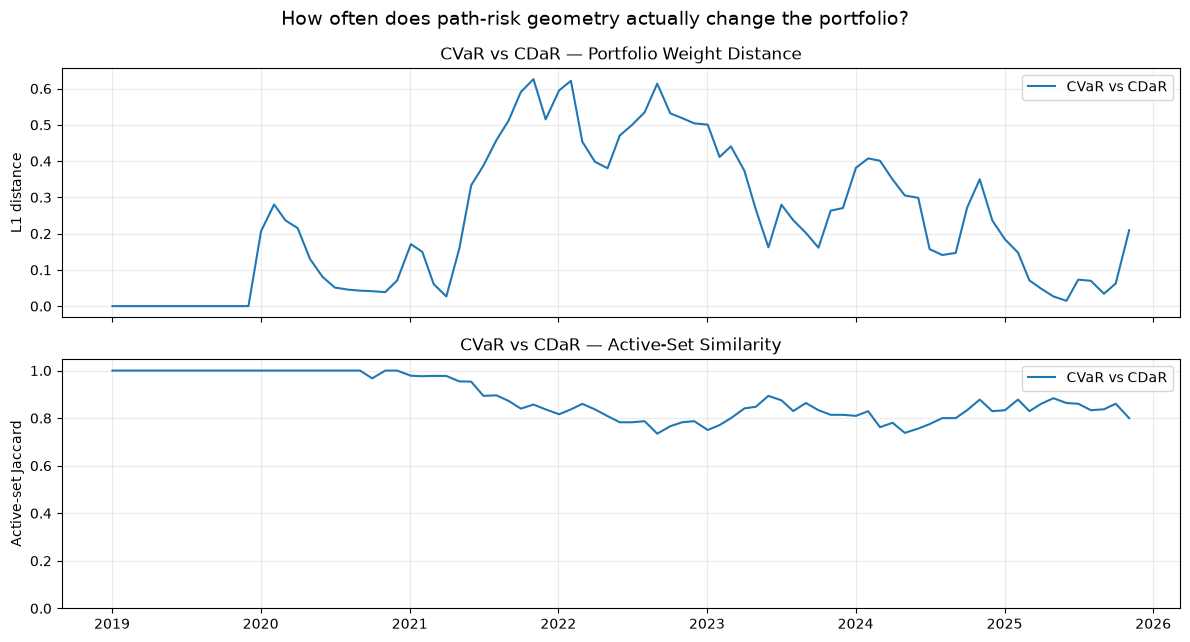

,count,mean,std,min,25%,50%,75%,max
CVaR turnover,82.0,0.124113,0.068445,0.014621,0.073707,0.107137,0.161230,0.345874
CDaR turnover,82.0,0.127486,0.060537,0.029607,0.087858,0.115292,0.161091,0.345662


In [19]:
def weights(folder):
    p=folder/"weights.xlsx"; out={}
    if not p.exists(): return out
    xl=pd.ExcelFile(p)
    for sh in xl.sheet_names:
        d=xl.parse(sh); key="Key" if "Key" in d else d.columns[0]
        if "weights" not in d: continue
        s=pd.Series(pd.to_numeric(d.weights,errors="coerce").fillna(0).values,index=d[key].astype(str))
        try: dt=pd.to_datetime(sh)
        except: continue
        out[dt]=s
    return out

def turn(W):
    m=sorted(W); o={}
    for i in range(1,len(m)):
        ix=W[m[i-1]].index.union(W[m[i]].index)
        o[m[i]]=0.5*np.abs(W[m[i]].reindex(ix).fillna(0)-W[m[i-1]].reindex(ix).fillna(0)).sum()
    return pd.Series(o)

wc,wd=weights(CVAR_DIR),weights(CDAR_DIR)
months=sorted(set(wc).intersection(wd)); rows=[]
for dt in months:
    ix=wc[dt].index.union(wd[dt].index); a=wc[dt].reindex(ix).fillna(0); b=wd[dt].reindex(ix).fillna(0)
    A=set(a[a>1e-9].index); B=set(b[b>1e-9].index)
    rows.append({"date":dt,"l1_weight_distance":float(np.abs(a-b).sum()),"jaccard":len(A&B)/len(A|B) if A|B else 1.0,
                 "cvar_active":len(A),"cdar_active":len(B)})
wcmp=pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()
# if not wcmp.empty:
#     display(wcmp.describe().T)
#     fig,axes=plt.subplots(2,1,figsize=(12,6.5),sharex=True)
#     axes[0].plot(wcmp.index,wcmp.l1_weight_distance, label="L1 distance (CVaR vs CDaR)"); axes[0].set_ylabel("L1 distance")
#     axes[0].legend(loc="upper left")
#     axes[1].plot(wcmp.index,wcmp.jaccard, label="Active-set Jaccard (CVaR vs CDaR)"); axes[1].set_ylabel("Active-set Jaccard"); axes[1].set_ylim(0,1.05)
#     axes[1].legend(loc="upper left")
#     for a in axes: a.grid(alpha=.25)
#     axes[0].set_title("How often does path-risk geometry actually change the portfolio?"); plt.tight_layout(); plt.show()

#     tc,td=turn(wc),turn(wd); display(pd.DataFrame({"CVaR turnover":tc,"CDaR turnover":td}).describe().T)
if not wcmp.empty:
    display(wcmp.describe().T)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

    axes[0].plot(
        wcmp.index,
        wcmp.l1_weight_distance,
        label="CVaR vs CDaR"
    )
    axes[0].set_ylabel("L1 distance")
    axes[0].set_title("CVaR vs CDaR — Portfolio Weight Distance")
    axes[0].legend()

    axes[1].plot(
        wcmp.index,
        wcmp.jaccard,
        label="CVaR vs CDaR"
    )
    axes[1].set_ylabel("Active-set Jaccard")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("CVaR vs CDaR — Active-Set Similarity")
    axes[1].legend()

    for a in axes:
        a.grid(alpha=.25)

    fig.suptitle(
        "How often does path-risk geometry actually change the portfolio?",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    tc, td = turn(wc), turn(wd)

    display(
        pd.DataFrame({
            "CVaR turnover": tc,
            "CDaR turnover": td
        }).describe().T
    )


,count,mean,std,min,25%,50%,75%,max
CVaR,82.0,0.124113,0.068445,0.014621,0.073707,0.107137,0.161230,0.345874
CDaR,82.0,0.127486,0.060537,0.029607,0.087858,0.115292,0.161091,0.345662


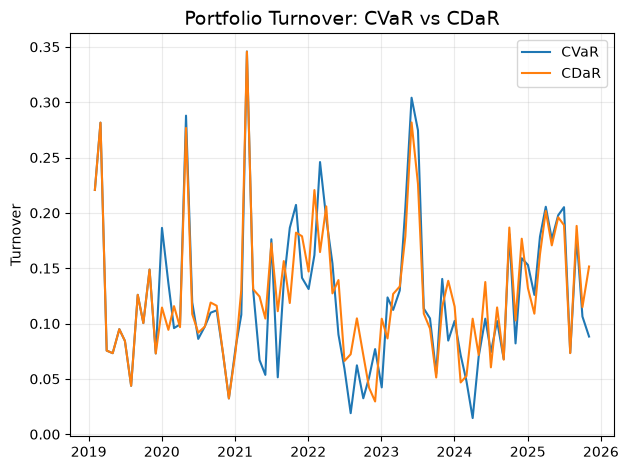

In [20]:
tc, td = turn(wc), turn(wd)

turnover_df = pd.DataFrame({
    "CVaR": tc,
    "CDaR": td
})

display(turnover_df.describe().T)

fig = plt.plot(figsize=(12, 6.5))

plt.plot(
    turnover_df.index,
    turnover_df["CVaR"],
    label="CVaR"
)
plt.plot(
    turnover_df.index,
    turnover_df["CDaR"],
    label="CDaR"
)
plt.ylabel("Turnover")
plt.title("CVaR Portfolio Turnover")
plt.legend()
plt.grid(alpha=.25)

plt.title("Portfolio Turnover: CVaR vs CDaR", fontsize=14)

plt.tight_layout()
plt.show()


## 7. Repository-generated paired comparison artifacts

In [21]:
if PAIR_DIR.exists():
    for name in ["cvar_cdar_metrics.csv","cvar_cdar_paired_bootstrap.csv","cvar_cdar_forward_risk_summary.csv","cvar_cdar_mechanism_summary.csv","cvar_cdar_weight_distance.csv"]:
        p=PAIR_DIR/name
        if p.exists():
            print("\n",name); display(pd.read_csv(p))
else:
    print("No results/cvar_cdar_comparison yet. Run scripts/runs/compare_cvar_cdar.py or set RUN_MATCHED_PAIR=True.")



 cvar_cdar_metrics.csv


,arm,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Average Drawdown,Calmar Ratio,VaR (95%),...,Treynor Ratio,Tracking Error,Information Ratio,PSR,DSR,DSR Benchmark E[max SR],Number of Trials,Trial Sharpe Mean,Trial Sharpe Std,N Periods
0,CVaR,1.756258,0.155854,0.208127,0.705694,1.14345,-0.153407,-0.055772,1.015950,-0.082587,...,NaN,NaN,NaN,0.967530,0.967530,0.0,1.0,0.0,0.0,84.0
1,CDaR,1.737516,0.154728,0.191646,0.744547,1.24029,-0.141114,-0.048132,1.096473,-0.077248,...,NaN,NaN,NaN,0.973768,0.973768,0.0,1.0,0.0,0.0,84.0



 cvar_cdar_paired_bootstrap.csv


,comparison,estimate,p_treatment_better,ci_2_5,ci_97_5
0,CDaR minus CVaR Sharpe,0.038853,0.8386,-0.040837,0.115099
1,CDaR minus CVaR max drawdown (positive=shallower),0.012293,0.9598,-0.003017,0.062299



 cvar_cdar_forward_risk_summary.csv


,arm,months,mean_cvar_model_centered,std_cvar_model_centered,mean_cdar_model_centered,std_cdar_model_centered,mean_target_risky_exposure,std_target_risky_exposure,mean_forward_cvar_timer,std_forward_cvar_timer,mean_forward_cdar_timer,std_forward_cdar_timer,mean_forward_risk_timer,std_forward_risk_timer,mean_overlay_fraction,std_overlay_fraction
0,CVaR,83,0.143232,0.044532,0.120914,0.037746,1.0,2.452072e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CDaR,83,0.129132,0.034382,0.108870,0.028850,1.0,4.247114e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Export notebook comparison tables

In [22]:
OUT=PAIR_DIR/"notebook_analysis"; OUT.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"CVaR":metrics(cvar),"CDaR":metrics(cdar)}).T.to_csv(OUT/"paired_performance_summary.csv")
r.to_csv(OUT/"paired_monthly_returns.csv")
summary.to_csv(OUT/"paired_block_bootstrap_summary.csv")
if not wcmp.empty: wcmp.to_csv(OUT/"paired_weight_mechanism.csv")
print("Saved",OUT)


Saved /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/cvar_cdar_comparison/notebook_analysis
